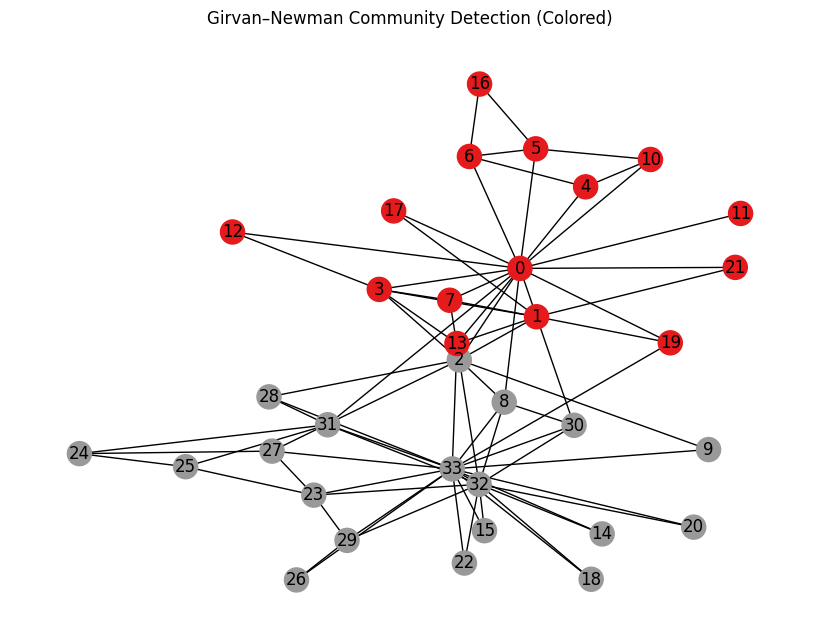

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import SpectralEmbedding

# Load dataset
G = nx.karate_club_graph()

# -------- Girvan–Newman --------
def girvan_newman(G):
    G = G.copy()
    while len(list(nx.connected_components(G))) == 1:
        eb = nx.edge_betweenness_centrality(G)
        G.remove_edge(*max(eb, key=eb.get))
    return list(nx.connected_components(G))

communities = girvan_newman(G)

# Assign colors
color_map = {}
for i, c in enumerate(communities):
    for node in c:
        color_map[node] = i

colors = [color_map[n] for n in G.nodes()]

# -------- K-Means (optional analysis) --------
X = SpectralEmbedding(n_components=5).fit_transform(nx.to_numpy_array(G))
kmeans_labels = KMeans(n_clusters=2, n_init=10).fit_predict(X)

# -------- Diagram --------
plt.figure(figsize=(8,6))
nx.draw(G, node_color=colors, with_labels=True, cmap=plt.cm.Set1)
plt.title("Girvan–Newman Community Detection (Colored)")
plt.show()